# Module 1 Lab 3 — Hands-On Problem 1.2: Choosing an Insurance Provider

**Name:** *[roey kadur]*  
**Course:** *[CS 82A: Introduction to Data Science]*  
**GitHub Repo:** *[https://github.com/roee0910/data-course-portfolio.git]*

**Problem (paraphrased from the textbook, Hands-On Problem 1.2):** An imaginary dataset gives three ratings each (from the three most recent customers) for three auto insurance providers. Using only these ratings, which provider should be chosen, and why?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## 1. The Raw Data


In [2]:
data = {
    "Insurance Provider": ["GEICO", "GEICO", "GEICO",
                            "Progressive", "Progressive", "Progressive",
                            "USAA", "USAA", "USAA"],
    "Rating": [4.7, 8.3, 9.2,
               7.4, 6.7, 8.9,
               3.8, 6.3, 8.1]
}
ratings_df = pd.DataFrame(data)
print(ratings_df.to_string(index=False))

Insurance Provider  Rating
             GEICO     4.7
             GEICO     8.3
             GEICO     9.2
       Progressive     7.4
       Progressive     6.7
       Progressive     8.9
              USAA     3.8
              USAA     6.3
              USAA     8.1


## 2. Summary Statistics: Min, Mean, Max per Provider

The average alone can be misleading. The **minimum** rating tells us about the worst experience a customer actually reported.


In [3]:
summary = ratings_df.groupby("Insurance Provider")["Rating"].agg(["min", "mean", "max"]).round(2)
summary = summary.reindex(["GEICO", "Progressive", "USAA"])
print(summary.to_string())

                    min  mean  max
Insurance Provider                
GEICO               4.7  7.40  9.2
Progressive         6.7  7.67  8.9
USAA                3.8  6.07  8.1


## 3. Visualizing the Risk Trade-off

Each point below is the **mean** rating; the bars extend down to the **minimum** and up to the **maximum** reported rating, so the length of each bar shows how much the experience varied for that provider.


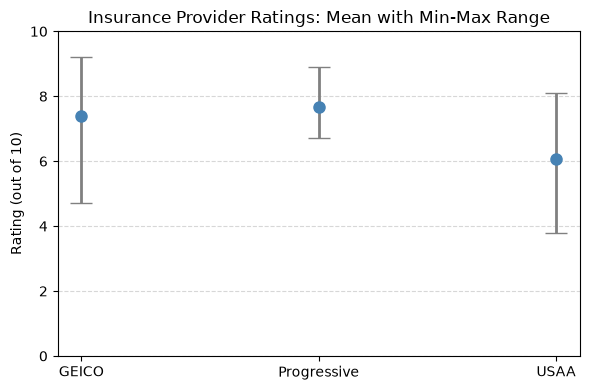

In [4]:
providers = summary.index
means = summary["mean"]
mins = summary["min"]
maxs = summary["max"]
lower_err = means - mins
upper_err = maxs - means

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(providers, means, yerr=[lower_err, upper_err], fmt='o', capsize=8,
            markersize=8, color='steelblue', ecolor='gray', elinewidth=2)
ax.set_ylabel("Rating (out of 10)")
ax.set_title("Insurance Provider Ratings: Mean with Min-Max Range")
ax.set_ylim(0, 10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Analysis and Recommendation

*(Replace this cell with your own answer, 5–8 sentences. Per the course AI-Use Policy, this reasoning must be your own words. Make sure you: name ONE provider, explicitly discuss the minimum/worst-case rating — not just the mean — and explain the trade-off in plain English, as if to a manager.)*

I would choose Progressive as the insurance provider. Its average rating is the highest of the three providers at 7.67. More importantly, its lowest rating is 6.7, which is higher than the lowest ratings for GEICO and USAA. This means that even the worst experience reported by a Progressive customer was still fairly positive. GEICO has a slightly lower average rating of 7.40, but its minimum rating is only 4.7, so there is more risk of having a bad experience. USAA has both the lowest average rating and the lowest minimum rating, which makes it the weakest choice based on this data. Overall, Progressive seems like the safest choice because it has the highest average rating while also having the best worst-case rating.
